# Лекция: Domain Shift + Наивный Байес + Метрики (демо + домашка)


In [8]:

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from typing import List, Tuple

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams["figure.dpi"] = 140
RANDOM_STATE = 29
np.random.seed(RANDOM_STATE)


## Вспомогательные функции



In [9]:

TOKEN_RE =  re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)*|\d+", re.UNICODE)

def simple_tokenize(text: str) -> List[str]:
    return TOKEN_RE.findall(text.lower())

def chunk_tokens(tokens: List[str], chunk_size: int = 200, min_frac: float = 0.5) -> List[str]:

    chunks = []
    min_len = int(chunk_size * min_frac)
    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i+chunk_size]
        if len(chunk) >= min_len:
            chunks.append(" ".join(chunk))
    return chunks

def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):

    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}
    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)
    return deltas

def top_log_odds_words(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        ca.update(simple_tokenize(t))
    for t in texts_b:
        cb.update(simple_tokenize(t))
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg


# Часть A — Domain shift и различия распределений

## A1. 20 Newsgroups: темы как «домены»


In [10]:
from datasets import load_dataset
import pandas as pd
from collections import Counter

ds = load_dataset("data-silence/rus_news_classifier")

TEXT_COL = "news"
LABEL_COL = "labels"
train = ds["train"]

counts = Counter(train[LABEL_COL])
counts_sorted = sorted(counts.items())

label2name = {
    0: "climate",
    1: "conflicts",
    2: "culture",
    3: "economy",
    4: "gloss",
    5: "health",
    6: "politics",
    7: "science",
    8: "society",
    9: "sports",
    10:"travel"
}

[(k, label2name.get(k, k), v) for k, v in counts_sorted]

dom_a = 1
dom_b = 4

texts_a = [r[TEXT_COL] for r in train if r[LABEL_COL] == dom_a]
texts_b = [r[TEXT_COL] for r in train if r[LABEL_COL] == dom_b]

# иначе 
texts_a = texts_a[:5000]
texts_b = texts_b[:5000]

len(texts_a), len(texts_b), label2name[dom_a], label2name[dom_b]


(5000, 5000, 'conflicts', 'gloss')

In [11]:
pos, neg = top_log_odds_words(texts_a, texts_b, top_n=30, alpha=0.1)

print("A >> B (top +):")
for w, d in pos:
    print(f"{w:20s} {d:.3f}")

print("\nB >> A (top -):")
for w, d in neg:
    print(f"{w:20s} {d:.3f}")


A >> B (top +):
теракт               7.502
истребитель          7.198
танков               7.129
идлиб                7.108
ливии                7.097
ланцет               6.997
идлибе               6.949
магнитудой           6.898
спецназа             6.789
взрывное             6.729
пехоты               6.698
сбили                6.666
поражать             6.666
кабула               6.615
абэ                  6.615
абу                  6.525
боеприпас            6.506
боевую               6.506
бастрыкин            6.487
херсонской           6.487
фаб                  6.467
росгвардейцы         6.447
сирийская            6.447
залпового            6.447
ксир                 6.426
рсзо                 6.384
самолетного          6.362
расправы             6.339
гаити                6.339
бомб                 6.317

B >> A (top -):
знаменитость         -8.862
откровенном          -8.008
предстала            -7.876
кардашьян            -7.796
бикини               -7.792
манекенщица      

### Распределение длины документов (токены)

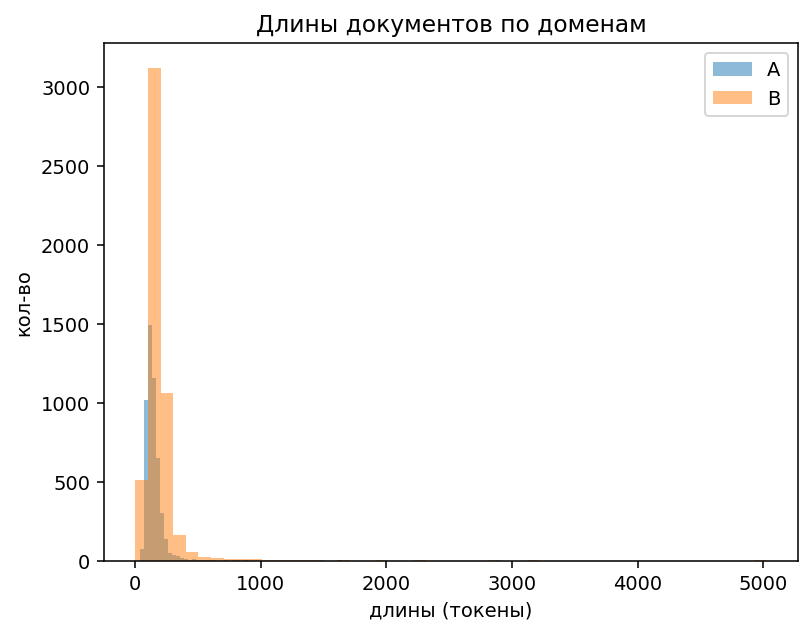

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

df_len = pd.DataFrame({
    "len_tokens": [len(simple_tokenize(t)) for t in (texts_a + texts_b)],
    "domain": (["A"] * len(texts_a)) + (["B"] * len(texts_b))
})

plt.figure()
for dom, g in df_len.groupby("domain"):
    plt.hist(g["len_tokens"], bins=50, alpha=0.5, label=dom)
plt.legend()
plt.title("Длины документов по доменам")
plt.xlabel("длины (токены)")
plt.ylabel("кол-во")
plt.show()

### Zipf: частоты топ-100 токенов (по доменам)

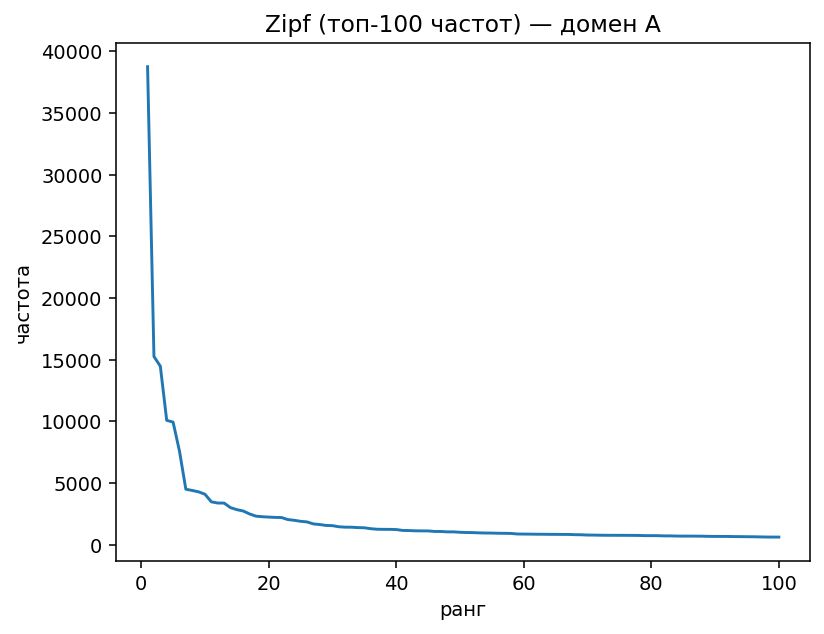

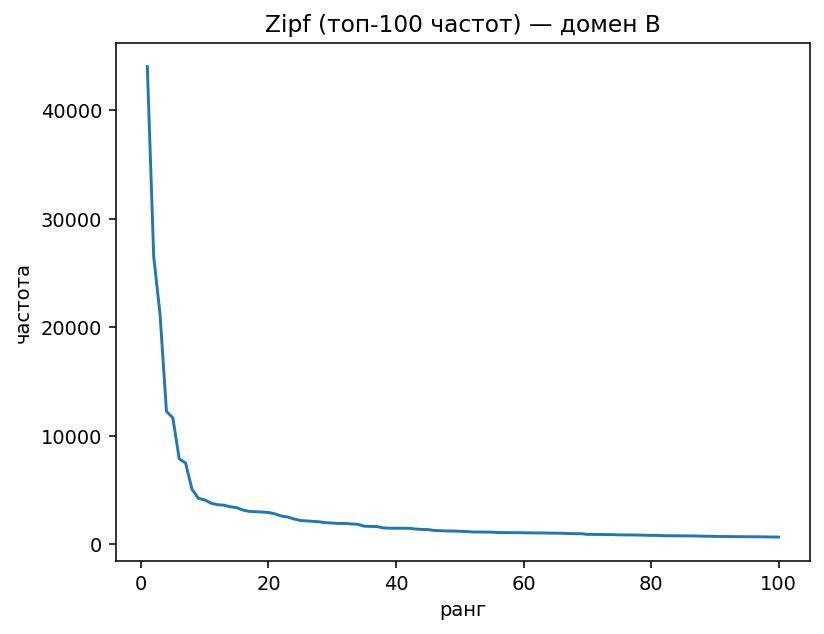

In [23]:
from collections import Counter

def token_counts(texts):
    c = Counter()
    for t in texts:
        c.update(simple_tokenize(t))
    return c

ca = token_counts(texts_a)
cb = token_counts(texts_b)

topA = [x[1] for x in ca.most_common(100)]
topB = [x[1] for x in cb.most_common(100)]

plt.figure()
plt.plot(range(1, 101), topA)
plt.title("Zipf (топ-100 частот) — домен A")
plt.xlabel("ранг")
plt.ylabel("частота")
plt.show()

plt.figure()
plt.plot(range(1, 101), topB)
plt.title("Zipf (топ-100 частот) — домен B")
plt.xlabel("ранг")
plt.ylabel("частота")
plt.show()

### Доля чисел/пунктуации

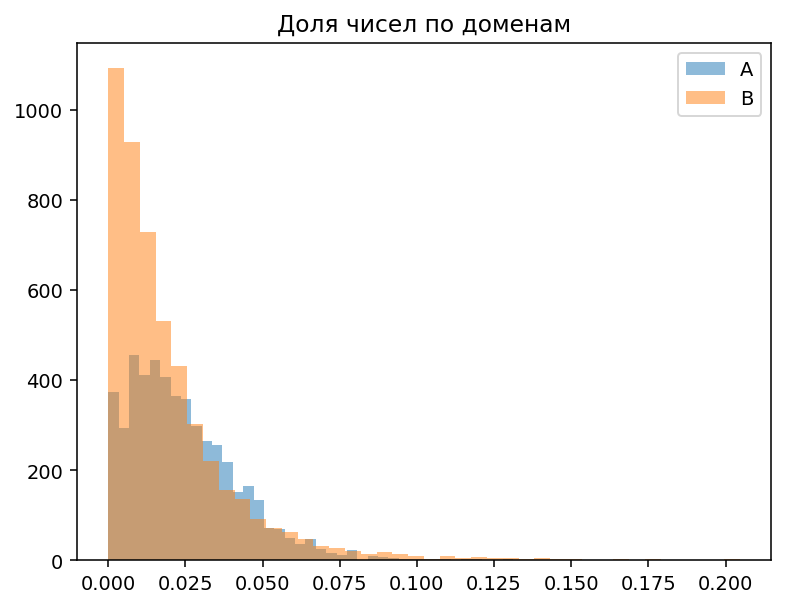

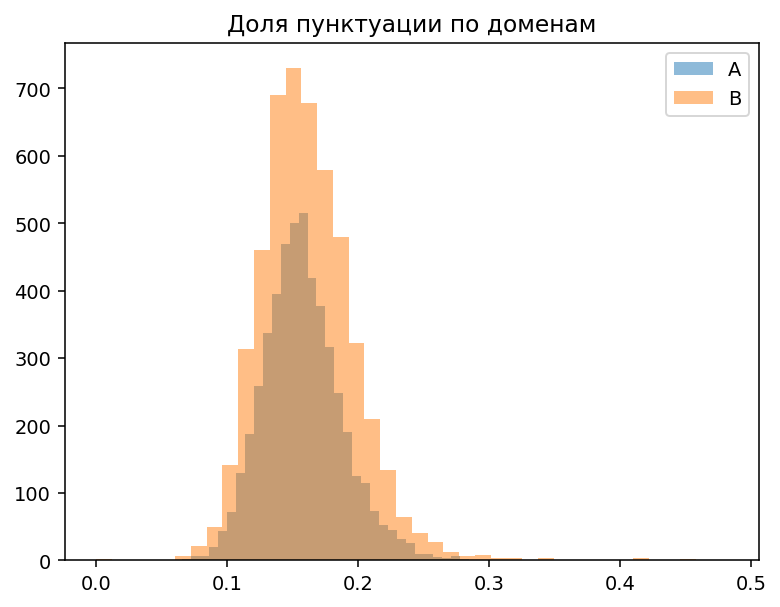

In [13]:
TOKEN_RE_ALL = re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)*|\d+|[^\s]", re.UNICODE)

def tokenize_all(text: str):
    return TOKEN_RE_ALL.findall(text.lower())

def ratios(text):
    toks = tokenize_all(text)
    if not toks:
        return 0.0, 0.0
    num = sum(t.isdigit() for t in toks) / len(toks)
    punct = sum(re.fullmatch(r"\W", t) is not None and not t.isdigit() for t in toks) / len(toks)
    return num, punct

ra = [ratios(t) for t in texts_a]
rb = [ratios(t) for t in texts_b]

df_np = pd.DataFrame({
    "num_ratio": [x[0] for x in ra] + [x[0] for x in rb],
    "punct_ratio": [x[1] for x in ra] + [x[1] for x in rb],
    "domain": ["A"]*len(ra) + ["B"]*len(rb)
})

plt.figure()
for dom, g in df_np.groupby("domain"):
    plt.hist(g["num_ratio"], bins=40, alpha=0.5, label=dom)
plt.legend()
plt.title("Доля чисел по доменам")
plt.show()

plt.figure()
for dom, g in df_np.groupby("domain"):
    plt.hist(g["punct_ratio"], bins=40, alpha=0.5, label=dom)
plt.legend()
plt.title("Доля пунктуации по доменам")
plt.show()

### Лемматизация (pymorphy3), стоп-слова, N-граммы, сравнение результатов

In [14]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

def lemmatize_tokens(tokens):
    out = []
    for w in tokens:
        if w.isdigit():
            out.append(w)
        else:
            out.append(morph.parse(w)[0].normal_form)
    return out

def tokenize_lemmas(text: str):
    return lemmatize_tokens(simple_tokenize(text))

from collections import Counter

def top_log_odds_words_tok(texts_a, texts_b, tokenize_fn, top_n=30, alpha=0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        ca.update(tokenize_fn(t))
    for t in texts_b:
        cb.update(tokenize_fn(t))
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

pos_lem, neg_lem = top_log_odds_words_tok(texts_a, texts_b, tokenize_lemmas, top_n=30)

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

RU_STOP = set(stopwords.words("russian"))

def tokenize_no_stop(text: str):
    toks = simple_tokenize(text)
    return [t for t in toks if t not in RU_STOP]


def add_bigrams(tokens):
    bigrams = [tokens[i] + "_" + tokens[i+1] for i in range(len(tokens)-1)]
    return tokens + bigrams

def tokenize_with_bigrams(text: str):
    toks = simple_tokenize(text)
    return add_bigrams(toks)


variants = {
    "base": simple_tokenize,
    "lemmas": tokenize_lemmas,
    "no_stop": tokenize_no_stop,
    "bigrams": tokenize_with_bigrams,
}

results = {}
for name, tok in variants.items():
    results[name] = top_log_odds_words_tok(texts_a, texts_b, tok, top_n=30)

for name, (posv, negv) in results.items():
    print("\n===", name, "===")
    print("A>>B:", [w for w,_ in posv[:10]])
    print("B>>A:", [w for w,_ in negv[:10]])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



=== base ===
A>>B: ['теракт', 'истребитель', 'танков', 'идлиб', 'ливии', 'ланцет', 'идлибе', 'магнитудой', 'спецназа', 'взрывное']
B>>A: ['знаменитость', 'откровенном', 'предстала', 'кардашьян', 'бикини', 'манекенщица', 'поклонники', 'лайков', 'позирует', 'декольте']

=== lemmas ===
A>>B: ['идлиб', 'ливия', 'гиперзвуковой', 'ланцет', 'диверсия', 'воздушно-космический', 'бастрыкин', 'высокоточный', 'абэ', 'авианосец']
B>>A: ['знаменитость', 'модный', 'макияж', 'манекенщица', 'кардашьян', 'гардероб', 'бикини', 'лайковый', 'героиня', 'юбка']

=== no_stop ===
A>>B: ['теракт', 'истребитель', 'танков', 'идлиб', 'ливии', 'ланцет', 'идлибе', 'магнитудой', 'спецназа', 'взрывное']
B>>A: ['знаменитость', 'откровенном', 'предстала', 'кардашьян', 'бикини', 'манекенщица', 'поклонники', 'лайков', 'позирует', 'декольте']

=== bigrams ===
A>>B: ['россии_скр', 'теракт', 'военный_эксперт', 'управлении_следственного', 'истребитель', 'танков', 'сектора_газа', 'идлиб', 'ливии', 'ру_сообщила']
B>>A: ['знаме